# Chapter 3. 멀티모달 모델을 위한 허깅페이스 라이브러리

## 3.1. 모델 불러오기

### 3.1.1. Base 클래스

In [2]:
from transformers import BertTokenizer, BertModel

# 모델 이름 지정
MODEL_NAME = "bert-base-uncased"

# Base Class 사용 시: 구체적인 클래스 지정 필요
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = BertModel.from_pretrained(MODEL_NAME)

# 입력 처리
text = "Hugging Face makes NLP easy."
inputs = tokenizer(text, return_tensors="pt")

# 추론
output = model(**inputs)
print(output.last_hidden_state.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([1, 9, 768])


### 3.1.2. Auto 클래스

In [3]:
from transformers import AutoTokenizer, AutoModel

# 모델 이름 지정
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

# 입력 처리
text = "Hugging Face makes NLP easy."
input = tokenizer(text, return_tensors="pt")

# 추론
output = model(**inputs)
print(output.last_hidden_state.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([1, 9, 768])


## 3.2. 데이터 불러오기

### 3.2.1. 허브에서 개별 파일 가져오기

In [4]:
from huggingface_hub import hf_hub_download

filepath = hf_hub_download(
   repo_id="woojun-jung/multimodal-guide-using-huggingface",
   repo_type="dataset",
   filename="Part-1/dog_image.jpg"
)
print(filepath)

Part-1/dog_image.jpg:   0%|          | 0.00/115k [00:00<?, ?B/s]

/root/.cache/huggingface/hub/datasets--woojun-jung--multimodal-guide-using-huggingface/snapshots/e635e4548aa57c19cb3eea3c1ae554bc9489c608/Part-1/dog_image.jpg


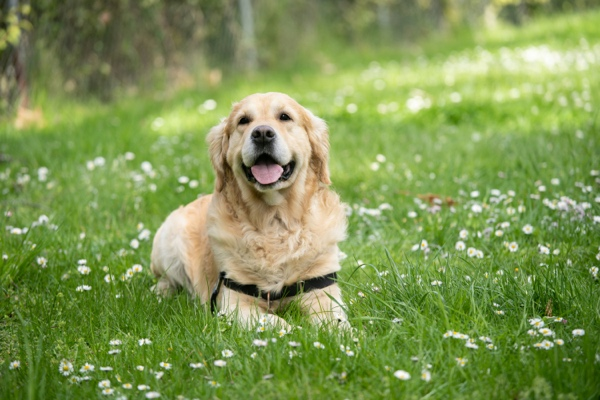

In [5]:
from transformers.image_utils import load_image


image = load_image(filepath)
image

### 3.2.2. 데이터셋 불러오기

In [6]:
from datasets import load_dataset

dataset = load_dataset("derek-thomas/ScienceQA")
dataset

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-1028f23e353fbe(…):   0%|          | 0.00/377M [00:00<?, ?B/s]

data/validation-00000-of-00001-6c7328ff6(…):   0%|          | 0.00/126M [00:00<?, ?B/s]

data/test-00000-of-00001-f0e719df791966f(…):   0%|          | 0.00/122M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12726 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4241 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4241 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'choices', 'answer', 'hint', 'task', 'grade', 'subject', 'topic', 'category', 'skill', 'lecture', 'solution'],
        num_rows: 12726
    })
    validation: Dataset({
        features: ['image', 'question', 'choices', 'answer', 'hint', 'task', 'grade', 'subject', 'topic', 'category', 'skill', 'lecture', 'solution'],
        num_rows: 4241
    })
    test: Dataset({
        features: ['image', 'question', 'choices', 'answer', 'hint', 'task', 'grade', 'subject', 'topic', 'category', 'skill', 'lecture', 'solution'],
        num_rows: 4241
    })
})

질문: Which of these states is farthest north?
선택지: ['West Virginia', 'Louisiana', 'Arizona', 'Oklahoma']
정답: West Virginia


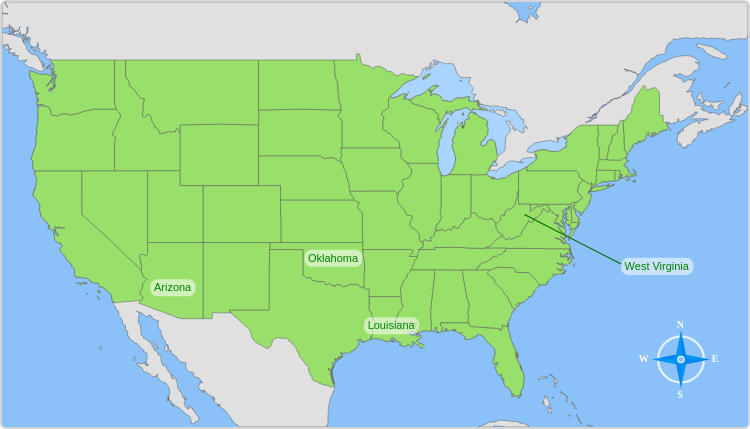

In [7]:
sample = dataset["train"][0]
print("질문:", sample["question"])
print("선택지:", sample["choices"])
print("정답:", sample["choices"][sample["answer"]])
sample["image"]

In [8]:
small_train = load_dataset("derek-thomas/ScienceQA", split="train[:5%]")
print(f"샘플 수: {len(small_train)}")

샘플 수: 636


### 3.2.3. 데이터 전처리

In [9]:
def format_choices(examples):
   formatted = []
   for choices in examples["choices"]:
       text = " ".join([f"({chr(65+i)}) {c}" for i, c in enumerate(choices)])
       formatted.append(text)
   examples["choices_text"] = formatted
   return examples

small_train = small_train.map(format_choices, batched=True)
print(small_train[0]["choices_text"])
print(small_train[10]["choices_text"])

Map:   0%|          | 0/636 [00:00<?, ? examples/s]

(A) West Virginia (B) Louisiana (C) Arizona (D) Oklahoma
(A) neither; their concentrations are the same (B) Solution B (C) Solution A


## 3.3. 토크나이저로 입력을 처리하기

### 3.3.1. 텍스트 토크나이저

In [10]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
text = "Hugging Face supports multimodal models."
tokens = tokenizer(text, return_tensors="pt")

print("Input IDs:", tokens["input_ids"])
print("Attention Mask:", tokens["attention_mask"])

Input IDs: tensor([[  101, 17662,  2227,  6753,  4800,  5302,  9305,  4275,  1012,   102]])
Attention Mask: tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


### 3.3.2. 이미지 프로세서

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


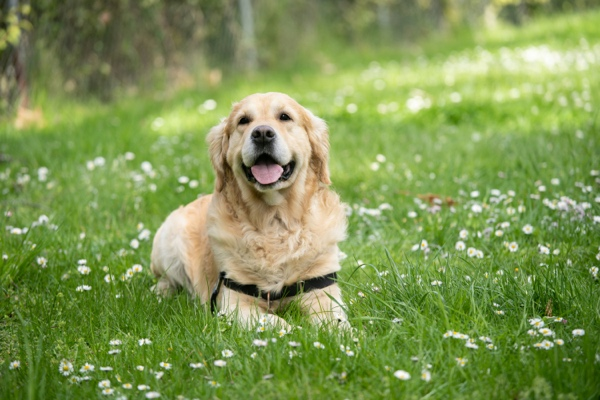

In [11]:
from transformers import AutoImageProcessor
from huggingface_hub import hf_hub_download
from PIL import Image

processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
image = Image.open(hf_hub_download(repo_id='woojun-jung/multimodal-guide-using-huggingface', repo_type='dataset', filename='Part-1/dog_image.jpg'))

image

In [12]:
inputs = processor(image, return_tensors="pt")
print("Pixel Values Shape:", inputs["pixel_values"].shape)

Pixel Values Shape: torch.Size([1, 3, 224, 224])


### 3.3.3 텍스트와 이미지의 통합 처리

In [13]:
from transformers import AutoProcessor, CLIPModel
from PIL import Image

processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

image = Image.open(hf_hub_download(repo_id='woojun-jung/multimodal-guide-using-huggingface', repo_type='dataset', filename='Part-1/dog_image.jpg'))
text = ["a photo of a cat", "a photo of a dog"]

inputs = processor(text=text, images=image, return_tensors="pt", padding=True)
outputs = model(**inputs)

print("Logits per image:", outputs.logits_per_image)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


vocab.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Logits per image: tensor([[21.3948, 28.3038]], grad_fn=<TBackward0>)


## 3.4. 파이프라인 시스템

transformers 5.0.0 이상 버전에서는 `image-to-text` 작업이 제거되어 4.49.0 버전으로 진행

In [ ]:
!pip install -q transformers==4.49.0

In [2]:
from transformers import pipeline
from huggingface_hub import hf_hub_download
from PIL import Image

captioner = pipeline("image-to-text", model="Salesforce/blip-image-captioning-base")
image = Image.open(hf_hub_download(repo_id='woojun-jung/multimodal-guide-using-huggingface', repo_type='dataset', filename='Part-1/dog_image.jpg'))

result = captioner(image)
print(result[0]["generated_text"])

Device set to use cpu


a golden retrieve dog sitting in the grass


In [3]:
vqa = pipeline("visual-question-answering", model="dandelin/vilt-b32-finetuned-vqa")
image = Image.open(hf_hub_download(repo_id='woojun-jung/multimodal-guide-using-huggingface', repo_type='dataset', filename='Part-1/dog_image.jpg'))

question = "What is the animal doing?"

result = vqa(image, question=question)
print(result)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/470M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/470M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/251 [00:00<?, ?B/s]

Device set to use cpu


[{'score': 0.3907562494277954, 'answer': 'sitting'}, {'score': 0.11214142292737961, 'answer': 'laying'}, {'score': 0.11104881763458252, 'answer': 'laying down'}, {'score': 0.06963882595300674, 'answer': 'watching'}, {'score': 0.0564933605492115, 'answer': 'standing'}]


In [4]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

image = Image.open(hf_hub_download(repo_id='woojun-jung/multimodal-guide-using-huggingface', repo_type='dataset', filename='Part-1/dog_image.jpg'))
texts = ["a photo of a cat", "a photo of a dog"]

inputs = processor(text=texts, images=image, return_tensors="pt", padding=True)
outputs = model(**inputs)

logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1)
print(probs)

tensor([[9.9562e-04, 9.9900e-01]], grad_fn=<SoftmaxBackward0>)
